# Análise Visual — Demografia e Previdência Social

Este notebook apresenta a etapa de análise exploratória e visual dos produtos consolidados na camada Gold.

O objetivo é transformar os indicadores demográficos e previdenciários construídos nas etapas anteriores em visualizações que auxiliem na interpretação dos resultados e na elaboração do artigo.

A análise será organizada em três perspectivas:

1. **Evolução histórica (2005–2023):** comportamento conjunto dos indicadores demográficos e previdenciários.
2. **Retrato recente (2022–2024):** participação dos contribuintes com 60 anos ou mais.
3. **Perspectiva demográfica (2023–2070):** transformação projetada da estrutura etária brasileira.

As projeções demográficas serão analisadas como cenários populacionais oficiais e não serão utilizadas para projetar diretamente o número futuro de contribuintes, benefícios ou aposentadorias.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pasta_gold = Path("dados/gold")

## Carregamento dos produtos da camada Gold

Os quatro produtos analíticos consolidados na camada Gold serão carregados para utilização nas análises e visualizações.

A leitura direta dos arquivos persistidos garante que esta etapa utilize exclusivamente os produtos finais produzidos pelo pipeline de dados.

In [2]:
df_demografia = pd.read_csv(
    pasta_gold / "gold_demografia.csv"
)

df_historico = pd.read_csv(
    pasta_gold / "gold_historico_previdencia.csv"
)

df_contribuintes_60 = pd.read_csv(
    pasta_gold / "gold_contribuintes_60_mais.csv"
)

df_comparacao_demografica = pd.read_csv(
    pasta_gold / "gold_comparacao_demografica.csv"
)

print("Demografia:", df_demografia.shape)
print("Histórico Previdência:", df_historico.shape)
print("Contribuintes 60+:", df_contribuintes_60.shape)
print("Comparação Demográfica:", df_comparacao_demografica.shape)

Demografia: (2343, 25)
Histórico Previdência: (19, 36)
Contribuintes 60+: (3, 6)
Comparação Demográfica: (10, 11)


## 1. Evolução histórica — 2005 a 2023

A primeira etapa da análise visual examina o período de 2005 a 2023, intervalo em que estão disponíveis simultaneamente os dados demográficos e previdenciários utilizados no estudo.

Inicialmente será observada a evolução da estrutura etária da população brasileira, permitindo contextualizar o cenário demográfico no qual ocorreu o comportamento histórico dos contribuintes, benefícios e aposentadorias.

### Evolução da população por grandes grupos etários

A evolução das populações de 0 a 14 anos, 15 a 64 anos e 60 anos ou mais permite visualizar as mudanças ocorridas na composição etária brasileira durante o período histórico analisado.

As séries são apresentadas em milhões de habitantes para facilitar a leitura e comparação das diferentes magnitudes populacionais.

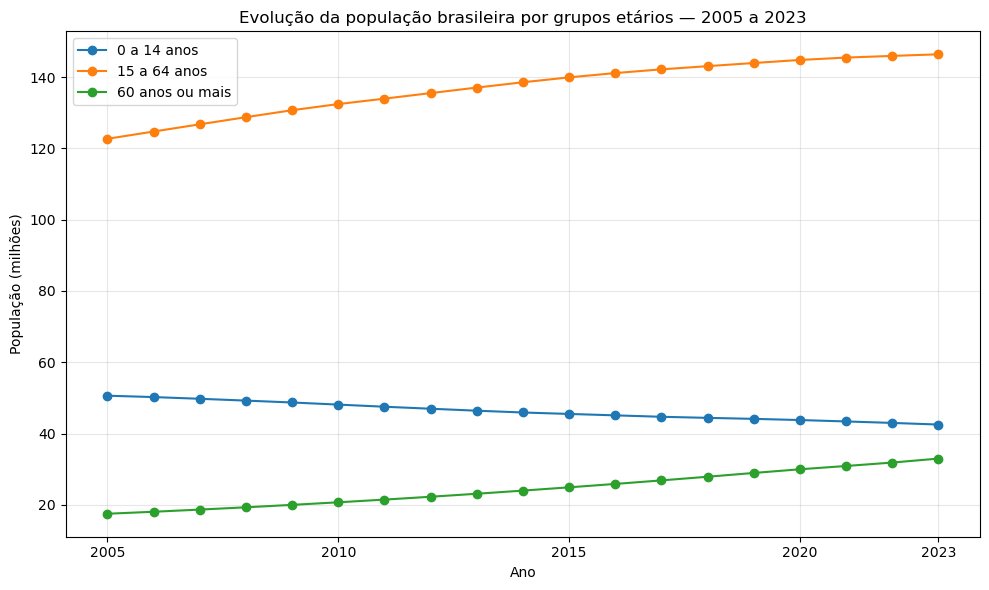

In [4]:
df_historico_plot = df_historico.copy()

df_historico_plot["populacao_0_14_milhoes"] = (
    df_historico_plot["populacao_0_14"] / 1_000_000
)

df_historico_plot["populacao_15_64_milhoes"] = (
    df_historico_plot["populacao_15_64"] / 1_000_000
)

df_historico_plot["populacao_60_mais_milhoes"] = (
    df_historico_plot["populacao_60_mais"] / 1_000_000
)

plt.figure(figsize=(10, 6))

plt.plot(
    df_historico_plot["ano"],
    df_historico_plot["populacao_0_14_milhoes"],
    marker="o",
    label="0 a 14 anos"
)

plt.plot(
    df_historico_plot["ano"],
    df_historico_plot["populacao_15_64_milhoes"],
    marker="o",
    label="15 a 64 anos"
)

plt.plot(
    df_historico_plot["ano"],
    df_historico_plot["populacao_60_mais_milhoes"],
    marker="o",
    label="60 anos ou mais"
)

plt.title("Evolução da população brasileira por grupos etários — 2005 a 2023")
plt.xlabel("Ano")
plt.ylabel("População (milhões)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(
    [2005, 2010, 2015, 2020, 2023]
)

plt.tight_layout()
plt.show()

### Evolução do índice de envelhecimento

O índice de envelhecimento permite observar a mudança na relação entre a população idosa e a população jovem.

Valores mais elevados indicam maior presença relativa da população idosa em comparação à população jovem. A evolução desse indicador complementa a análise dos grupos etários ao evidenciar a transformação da estrutura etária brasileira durante o período histórico.

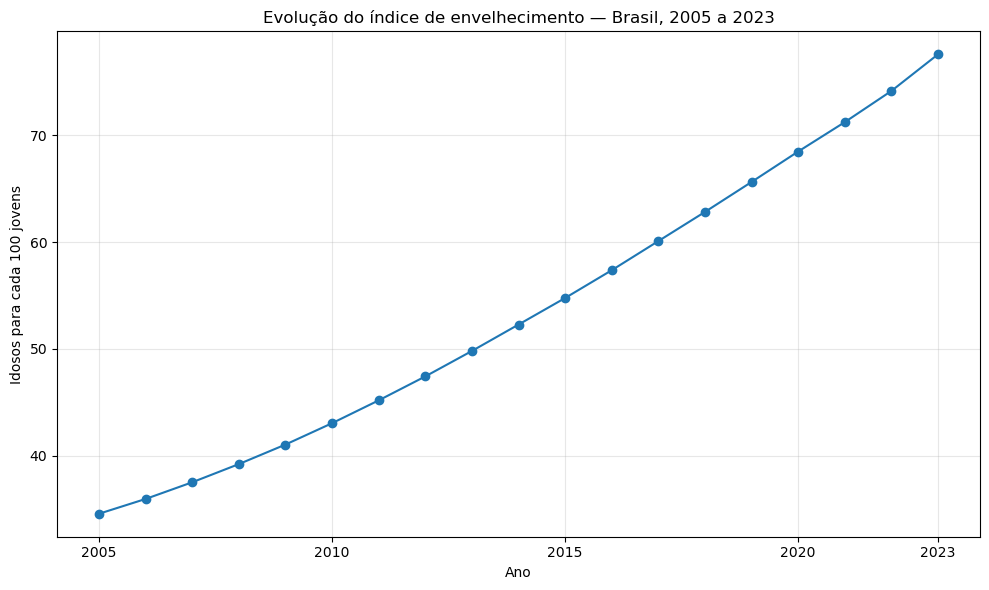

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(
    df_historico["ano"],
    df_historico["indice_envelhecimento"],
    marker="o"
)

plt.title("Evolução do índice de envelhecimento — Brasil, 2005 a 2023")
plt.xlabel("Ano")
plt.ylabel("Idosos para cada 100 jovens")

plt.xticks(
    [2005, 2010, 2015, 2020, 2023]
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evolução das relações entre contribuintes, benefícios e aposentadorias

Para observar o comportamento histórico da base contributiva em relação aos benefícios emitidos, serão analisadas duas relações descritivas: o número de contribuintes por benefício emitido e o número de contribuintes por aposentadoria emitida.

Esses indicadores representam relações entre quantidades agregadas e não devem ser interpretados como medidas de equilíbrio financeiro da Previdência ou como número de trabalhadores responsáveis pelo financiamento individual de cada benefício.

A análise permite identificar como essas relações evoluíram entre 2005 e 2023 e compará-las posteriormente ao processo de envelhecimento populacional observado no mesmo período.

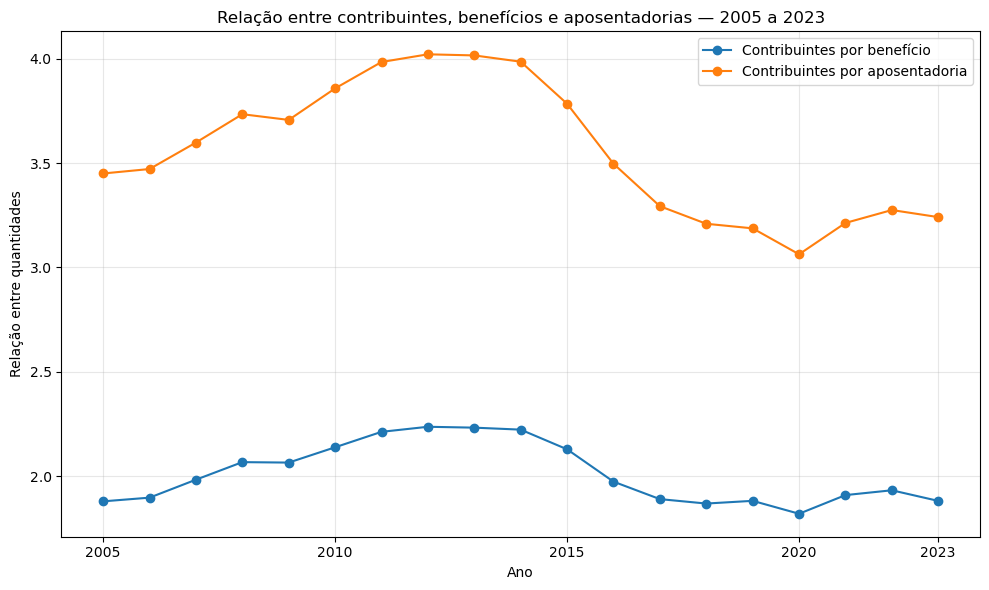

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(
    df_historico["ano"],
    df_historico["contribuintes_por_beneficio"],
    marker="o",
    label="Contribuintes por benefício"
)

plt.plot(
    df_historico["ano"],
    df_historico["contribuintes_por_aposentadoria"],
    marker="o",
    label="Contribuintes por aposentadoria"
)

plt.title(
    "Relação entre contribuintes, benefícios e aposentadorias — 2005 a 2023"
)
plt.xlabel("Ano")
plt.ylabel("Relação entre quantidades")

plt.xticks(
    [2005, 2010, 2015, 2020, 2023]
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evolução da razão de dependência dos idosos

A razão de dependência dos idosos complementa a análise do envelhecimento ao relacionar a população idosa à população em idade potencialmente ativa.

O indicador possui natureza demográfica e não representa uma relação direta entre aposentados e contribuintes da Previdência Social.

Sua evolução permite observar como a composição etária da população brasileira se modificou durante o período histórico e servirá posteriormente como referência para a análise das projeções demográficas.

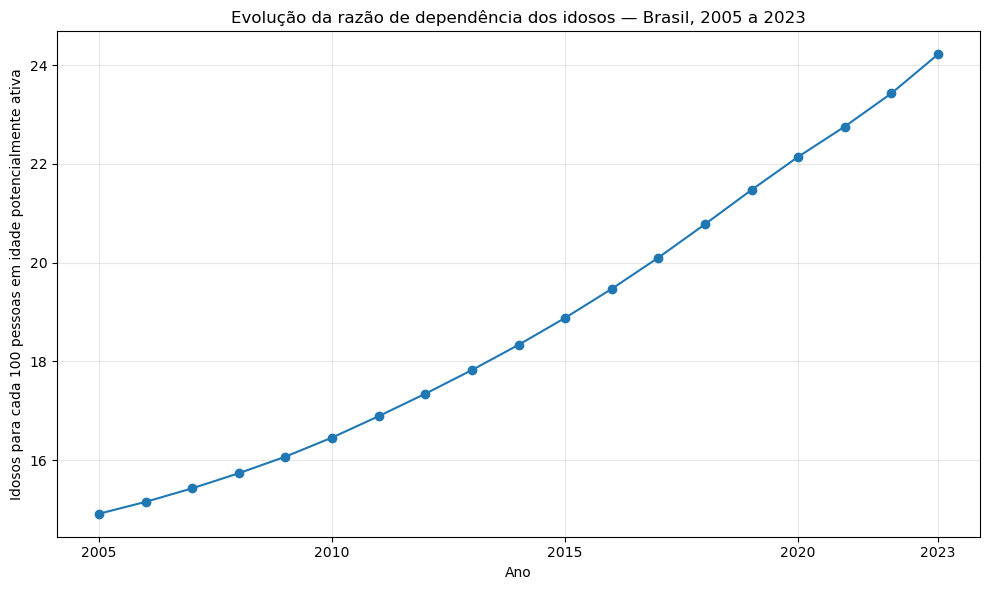

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(
    df_historico["ano"],
    df_historico["razao_dependencia_idosos"],
    marker="o"
)

plt.title(
    "Evolução da razão de dependência dos idosos — Brasil, 2005 a 2023"
)
plt.xlabel("Ano")
plt.ylabel("Idosos para cada 100 pessoas em idade potencialmente ativa")

plt.xticks(
    [2005, 2010, 2015, 2020, 2023]
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Retrato recente dos contribuintes — 2022 a 2024

A segunda etapa da análise visual examina a presença das pessoas com 60 anos ou mais entre os contribuintes da Previdência Social no período de 2022 a 2024.

A análise permite observar se a participação relativa desse grupo etário na base contributiva apresentou alterações no período recente.

Os resultados possuem caráter descritivo e não permitem identificar se os contribuintes com 60 anos ou mais são aposentados, nem determinar os motivos de sua permanência na atividade contributiva.

### Participação dos contribuintes com 60 anos ou mais

O gráfico apresenta o percentual de contribuintes com 60 anos ou mais em relação ao total de contribuintes em cada ano.

A comparação permite observar a evolução recente da participação desse grupo etário na composição da base contributiva.

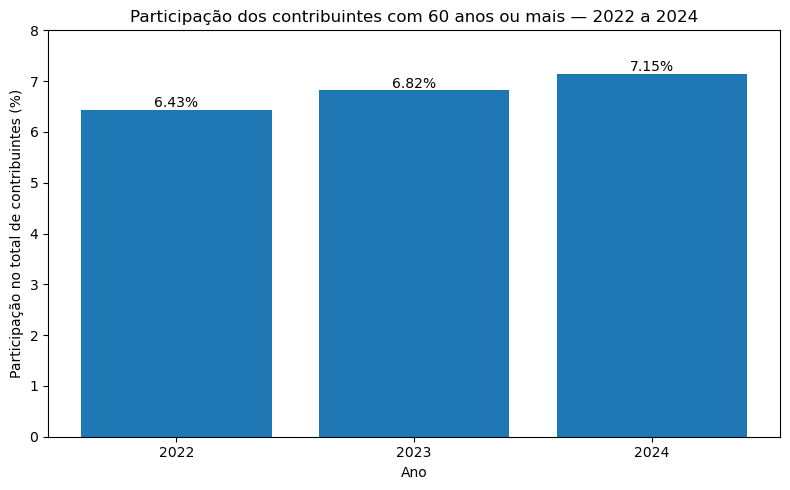

In [8]:
plt.figure(figsize=(8, 5))

barras = plt.bar(
    df_contribuintes_60["ano"].astype(str),
    df_contribuintes_60["percentual_contribuintes_60_mais"]
)

plt.title(
    "Participação dos contribuintes com 60 anos ou mais — 2022 a 2024"
)
plt.xlabel("Ano")
plt.ylabel("Participação no total de contribuintes (%)")

for barra, valor in zip(
    barras,
    df_contribuintes_60["percentual_contribuintes_60_mais"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.05,
        f"{valor:.2f}%",
        ha="center"
    )

plt.ylim(0, 8)

plt.tight_layout()
plt.show()

### Relação entre contribuintes com 60 anos ou mais e a população da mesma faixa etária

Além da participação dos indivíduos com 60 anos ou mais na base contributiva, será analisada a relação entre o número de contribuintes dessa faixa etária e a população brasileira com 60 anos ou mais.

O indicador permite comparar a evolução recente do número de contribuintes com 60 anos ou mais em relação ao tamanho da população pertencente ao mesmo grupo etário.

Essa relação não representa taxa de emprego ou participação na força de trabalho, pois a condição de contribuinte não permite identificar diretamente a situação ocupacional ou previdenciária de cada indivíduo.

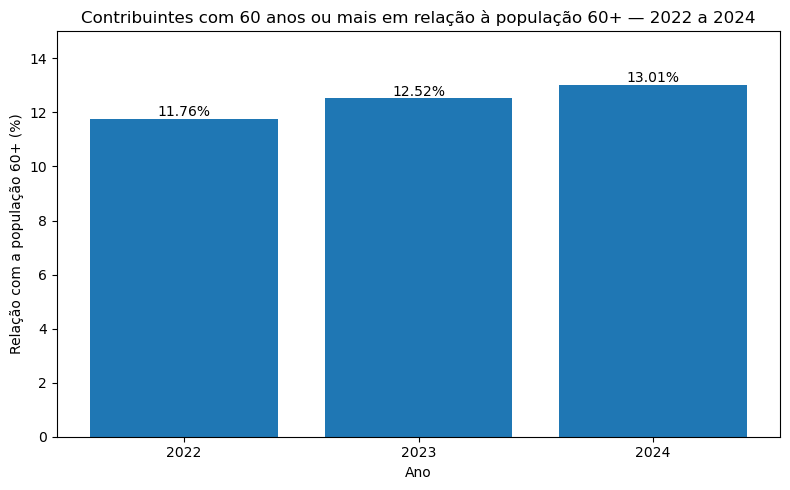

In [9]:
plt.figure(figsize=(8, 5))

barras = plt.bar(
    df_contribuintes_60["ano"].astype(str),
    df_contribuintes_60[
        "percentual_contribuintes_na_populacao_60_mais"
    ]
)

plt.title(
    "Contribuintes com 60 anos ou mais em relação à população 60+ — 2022 a 2024"
)
plt.xlabel("Ano")
plt.ylabel("Relação com a população 60+ (%)")

for barra, valor in zip(
    barras,
    df_contribuintes_60[
        "percentual_contribuintes_na_populacao_60_mais"
    ]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f"{valor:.2f}%",
        ha="center"
    )

plt.ylim(0, 15)

plt.tight_layout()
plt.show()

## 3. Perspectiva demográfica — 2023 a 2070

A terceira etapa da análise visual examina as projeções demográficas para as próximas décadas e as compara ao contexto observado no período histórico.

As projeções do IBGE permitem analisar como a estrutura etária brasileira poderá se transformar até 2070, especialmente em relação à população em idade potencialmente ativa e às populações com 60 e 65 anos ou mais.

Os valores projetados representam cenários demográficos e não serão utilizados para estimar diretamente a evolução futura do número de contribuintes, benefícios ou aposentadorias.

### Transformação da estrutura etária brasileira

A comparação entre anos históricos e projetados permite visualizar a mudança na trajetória dos principais grupos etários.

Enquanto o período histórico apresenta crescimento da população de 15 a 64 anos simultaneamente ao avanço da população idosa, as projeções permitem observar como essa relação poderá se modificar nas próximas décadas.

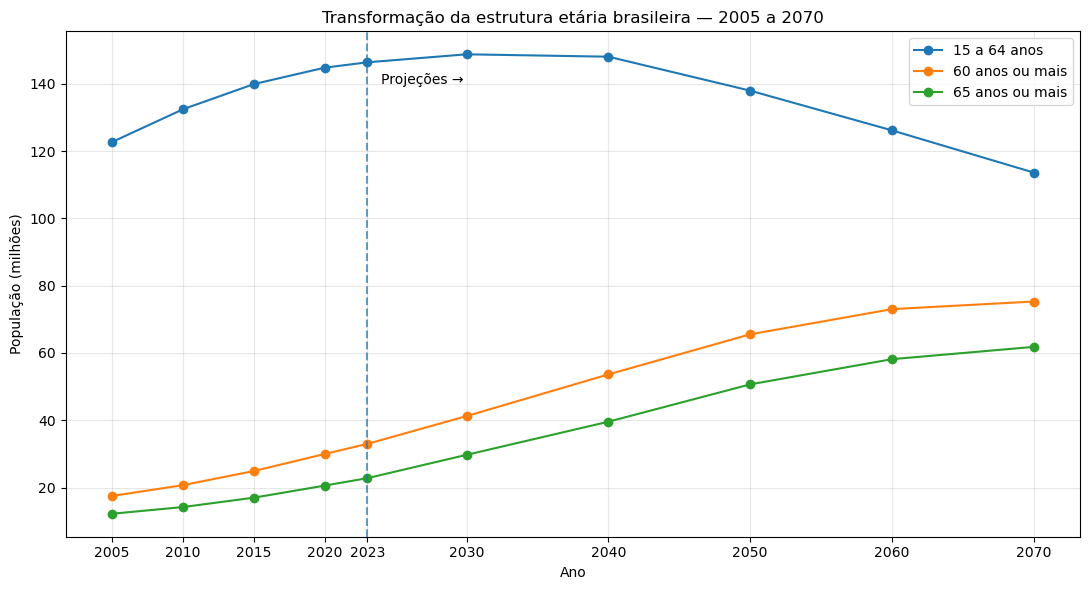

In [11]:
df_comparacao_plot = df_comparacao_demografica.copy()

df_comparacao_plot["populacao_15_64_milhoes"] = (
    df_comparacao_plot["populacao_15_64"] / 1_000_000
)

df_comparacao_plot["populacao_60_mais_milhoes"] = (
    df_comparacao_plot["populacao_60_mais"] / 1_000_000
)

df_comparacao_plot["populacao_65_mais_milhoes"] = (
    df_comparacao_plot["populacao_65_mais"] / 1_000_000
)

plt.figure(figsize=(11, 6))

plt.plot(
    df_comparacao_plot["ano"],
    df_comparacao_plot["populacao_15_64_milhoes"],
    marker="o",
    label="15 a 64 anos"
)

plt.plot(
    df_comparacao_plot["ano"],
    df_comparacao_plot["populacao_60_mais_milhoes"],
    marker="o",
    label="60 anos ou mais"
)

plt.plot(
    df_comparacao_plot["ano"],
    df_comparacao_plot["populacao_65_mais_milhoes"],
    marker="o",
    label="65 anos ou mais"
)

plt.axvline(
    x=2023,
    linestyle="--",
    alpha=0.7
)

plt.text(
    2024,
    140,
    "Projeções →"
)

plt.title(
    "Transformação da estrutura etária brasileira — 2005 a 2070"
)
plt.xlabel("Ano")
plt.ylabel("População (milhões)")

plt.xticks(
    df_comparacao_plot["ano"]
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Mudança na composição etária da população

Além das alterações nas quantidades absolutas, as projeções indicam mudanças relevantes na participação dos diferentes grupos etários na população brasileira.

A análise das proporções permite observar como o peso relativo da população de 15 a 64 anos tende a diminuir, enquanto as populações com 60 anos ou mais e 65 anos ou mais passam a representar parcelas crescentes da população total.

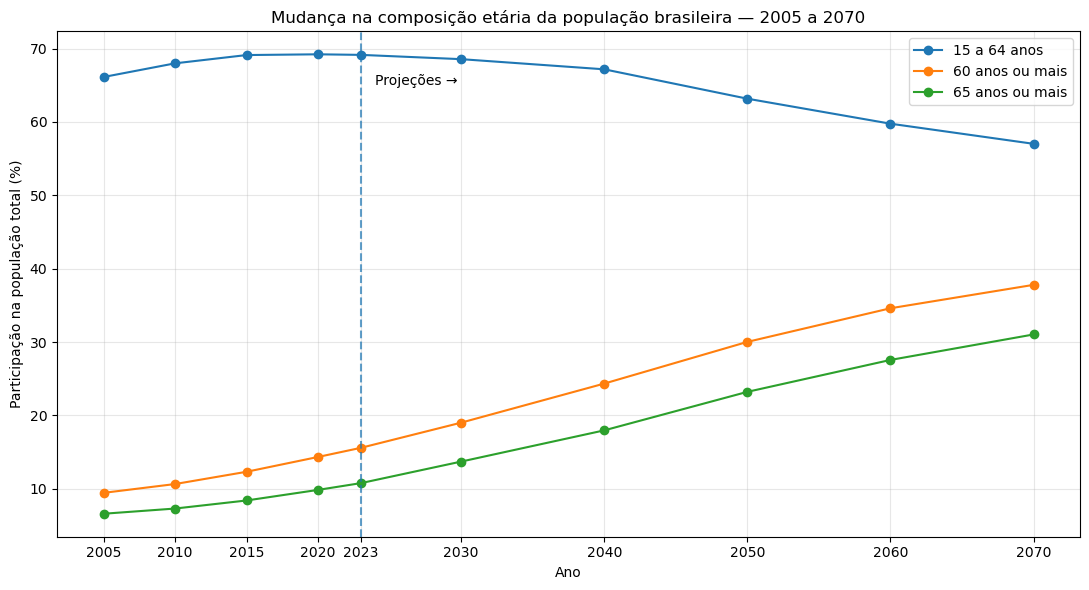

In [12]:
plt.figure(figsize=(11, 6))

plt.plot(
    df_comparacao_demografica["ano"],
    df_comparacao_demografica["proporcao_15_64"] * 100,
    marker="o",
    label="15 a 64 anos"
)

plt.plot(
    df_comparacao_demografica["ano"],
    df_comparacao_demografica["proporcao_60_mais"] * 100,
    marker="o",
    label="60 anos ou mais"
)

plt.plot(
    df_comparacao_demografica["ano"],
    df_comparacao_demografica["proporcao_65_mais"] * 100,
    marker="o",
    label="65 anos ou mais"
)

plt.axvline(
    x=2023,
    linestyle="--",
    alpha=0.7
)

plt.text(
    2024,
    65,
    "Projeções →"
)

plt.title(
    "Mudança na composição etária da população brasileira — 2005 a 2070"
)
plt.xlabel("Ano")
plt.ylabel("Participação na população total (%)")

plt.xticks(
    df_comparacao_demografica["ano"]
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evolução projetada do índice de envelhecimento

O índice de envelhecimento permite acompanhar a relação entre a população idosa e a população jovem ao longo do processo de transformação demográfica.

A linha de referência correspondente ao valor 100 representa o ponto em que há 100 idosos para cada 100 jovens. Valores superiores a esse nível indicam que a população idosa passa a superar numericamente a população jovem nas faixas etárias consideradas pelo indicador.

A comparação entre o período histórico e as projeções permite observar a intensidade esperada desse processo nas próximas décadas.

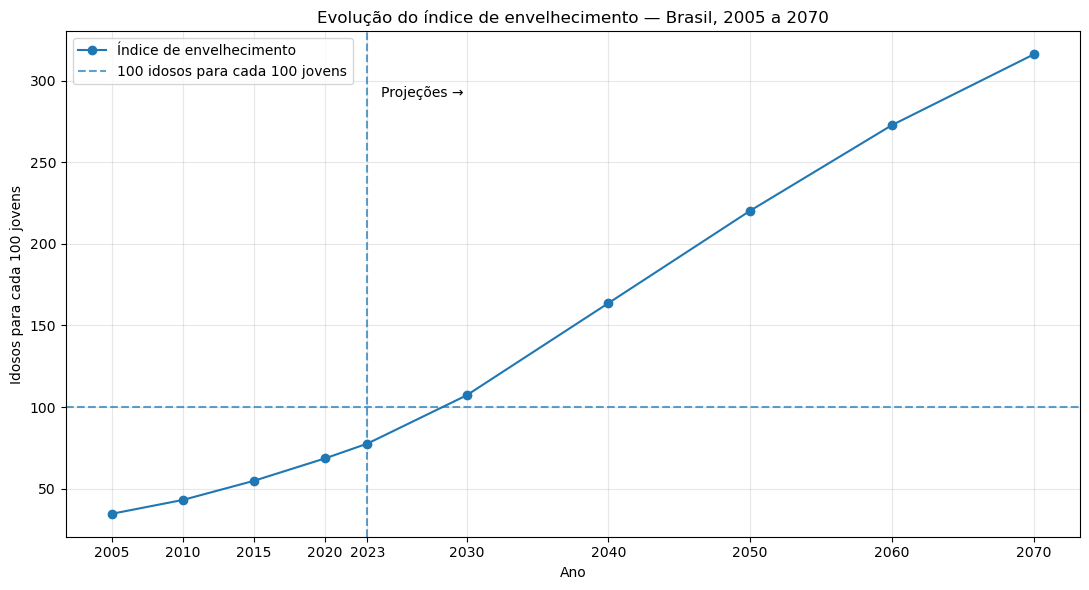

In [13]:
plt.figure(figsize=(11, 6))

plt.plot(
    df_comparacao_demografica["ano"],
    df_comparacao_demografica["indice_envelhecimento"],
    marker="o",
    label="Índice de envelhecimento"
)

plt.axhline(
    y=100,
    linestyle="--",
    alpha=0.7,
    label="100 idosos para cada 100 jovens"
)

plt.axvline(
    x=2023,
    linestyle="--",
    alpha=0.7
)

plt.text(
    2024,
    290,
    "Projeções →"
)

plt.title(
    "Evolução do índice de envelhecimento — Brasil, 2005 a 2070"
)
plt.xlabel("Ano")
plt.ylabel("Idosos para cada 100 jovens")

plt.xticks(
    df_comparacao_demografica["ano"]
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evolução projetada da razão de dependência dos idosos

A razão de dependência dos idosos relaciona a população idosa à população em idade potencialmente ativa e permite observar como essa relação poderá se modificar nas próximas décadas.

A análise conjunta do período histórico e das projeções demográficas evidencia a intensificação esperada dessa relação à medida que aumenta a população idosa e diminui a participação relativa da população em idade potencialmente ativa.

O indicador possui natureza exclusivamente demográfica e não representa a relação entre aposentados e contribuintes da Previdência Social.

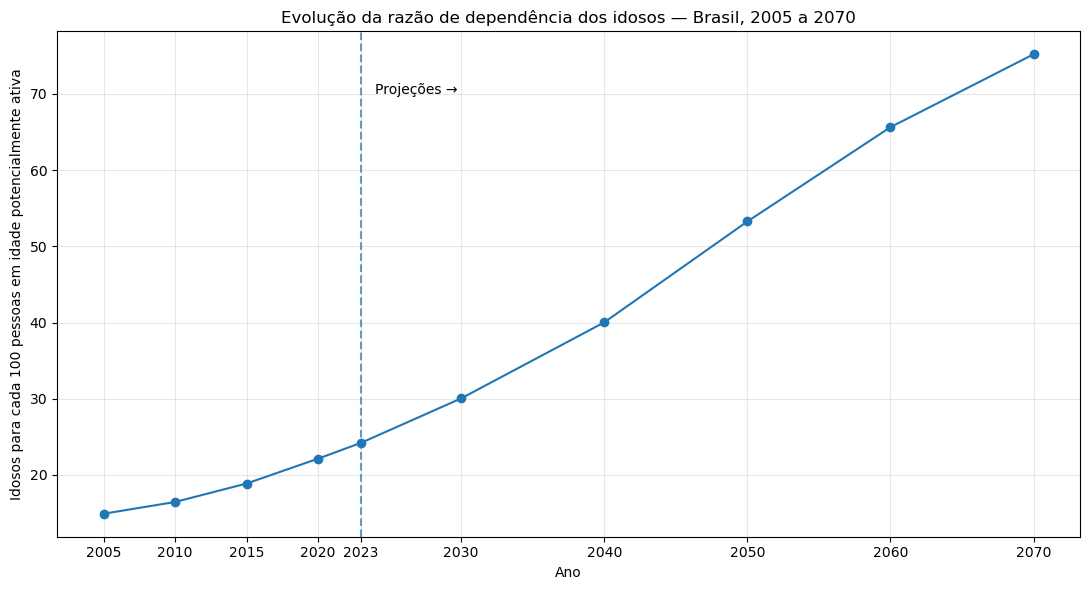

In [14]:
plt.figure(figsize=(11, 6))

plt.plot(
    df_comparacao_demografica["ano"],
    df_comparacao_demografica["razao_dependencia_idosos"],
    marker="o"
)

plt.axvline(
    x=2023,
    linestyle="--",
    alpha=0.7
)

plt.text(
    2024,
    70,
    "Projeções →"
)

plt.title(
    "Evolução da razão de dependência dos idosos — Brasil, 2005 a 2070"
)
plt.xlabel("Ano")
plt.ylabel(
    "Idosos para cada 100 pessoas em idade potencialmente ativa"
)

plt.xticks(
    df_comparacao_demografica["ano"]
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Síntese dos resultados da análise visual

As visualizações evidenciam uma transformação progressiva da estrutura etária brasileira ao longo do período analisado.

Entre 2005 e 2023, o envelhecimento populacional ocorreu simultaneamente ao crescimento da população de 15 a 64 anos. Nesse período, a população com 60 anos ou mais apresentou crescimento expressivo, enquanto a população jovem diminuiu e os indicadores de envelhecimento e dependência dos idosos aumentaram continuamente.

No mesmo período, as relações entre contribuintes, benefícios e aposentadorias apresentaram comportamento distinto dos indicadores demográficos. O número de contribuintes por benefício e por aposentadoria aumentou até aproximadamente 2012 e 2013 e posteriormente apresentou redução. Esse comportamento indica que a evolução histórica dessas relações não pode ser explicada exclusivamente pelo envelhecimento populacional.

No período recente de 2022 a 2024, observou-se crescimento da presença dos contribuintes com 60 anos ou mais. Sua participação no total de contribuintes passou de 6,43% para 7,15%, enquanto a relação entre o número de contribuintes com 60 anos ou mais e a população brasileira da mesma faixa etária passou de 11,76% para 13,01%.

As projeções demográficas indicam uma mudança mais intensa nas próximas décadas. Entre 2023 e 2070, projeta-se redução de 22,39% da população de 15 a 64 anos, enquanto as populações com 60 anos ou mais e 65 anos ou mais apresentam crescimento projetado de 128,29% e 171,21%, respectivamente.

A mudança também aparece na composição relativa da população. A participação da população de 15 a 64 anos passa de aproximadamente 69% em 2023 para 57% em 2070, enquanto a população com 60 anos ou mais passa de aproximadamente 16% para 38%.

O índice de envelhecimento, que era de 77,56 idosos para cada 100 jovens em 2023, ultrapassa o valor de 100 na projeção para 2030 e alcança 316,24 em 2070. No mesmo período, a razão de dependência dos idosos passa de 24,22 para 75,20 idosos para cada 100 pessoas em idade potencialmente ativa.

Os resultados demonstram que o contexto demográfico projetado para as próximas décadas difere significativamente daquele observado durante grande parte do período histórico analisado. Entretanto, esses resultados não permitem concluir isoladamente sobre a sustentabilidade financeira da Previdência Social, uma vez que essa questão também depende de fatores econômicos, trabalhistas, institucionais e das próprias regras do sistema previdenciário.